In [1]:
from pathlib import Path

import pandas as pd
from tqdm.notebook import tqdm

In [2]:
shiftable = {
    "DECT210 Waschmaschine": "uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb",    
    "DECT200 Waschmaschine": "uri:urn:4b29c04c920141e8",
    "Smart Switch 6 Spülmaschine": "uri:urn:e91f9319-71af-4ddb-ab7d-fb47b45d69ad",    
    "DECT200 Spülmaschine": "uri:urn:cc256ae649904024",
    # "Smart Switch 6 Thermomix": "uri:urn:5b59894b-805d-4d7c-96c9-8ab42a18c3c7",
}

hh_root = Path("../../../datasets/ForeSight/household-1235/")
ts_dirs = {k: Path(hh_root, fn) for k, fn in shiftable.items()}
ts_dirs

{'DECT210 Waschmaschine': PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb'),
 'DECT200 Waschmaschine': PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8'),
 'Smart Switch 6 Spülmaschine': PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:e91f9319-71af-4ddb-ab7d-fb47b45d69ad'),
 'DECT200 Spülmaschine': PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024')}

In [3]:
for k, td in ts_dirs.items():
    print(k)
    display(list(td.iterdir()))
    print("\n")

DECT210 Waschmaschine


[PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb/socket-on.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb/sensor_160-value.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb/sensor_163-value.csv')]



DECT200 Waschmaschine


[PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8/temperature.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8/onOff.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8/energy.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8/power.csv')]



Smart Switch 6 Spülmaschine


[PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:e91f9319-71af-4ddb-ab7d-fb47b45d69ad/sensor_582-value.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:e91f9319-71af-4ddb-ab7d-fb47b45d69ad/socket-on.csv')]



DECT200 Spülmaschine


[PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024/temperature.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024/onOff.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024/energy.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024/power.csv')]

In [4]:
def read_tables(thing_name: str, **kwargs):
    frames = []
    for p in tqdm(
        list(ts_dirs[thing_name].iterdir())# + 
    ):
        if p.suffix == ".csv" and any([
            p.stem == "energy",
            p.stem == "power",
            p.stem.startswith("sensor"),
        ]):
            df = pd.read_csv(
                p,
                usecols=["_time", "_value"],
                index_col="_time",
                parse_dates=True,
                date_format="ISO8601",
                **kwargs,
            )
            df.columns = [p.stem]
            df.astype(float)
            df = df.resample("1min").mean()
            frames.append(df)
    return pd.concat(frames, axis=1)


def cached_resample(thing_name: str):
    out_path = Path(f"../data/resampled/{thing_name}.csv")
    if out_path.exists() and out_path.is_file():
        print("reading from cache...")
        time_series = pd.read_csv(
            out_path, 
            index_col="_time",
            parse_dates=True,
            date_format="ISO8601"
        )
    else:
        print("resampling...")
        time_series = read_tables(thing_name=thing_name)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        time_series.to_csv(out_path)

    return time_series

In [5]:
series = {thing_name: cached_resample(thing_name) for thing_name in ts_dirs.keys()}

reading from cache...
reading from cache...
reading from cache...
reading from cache...


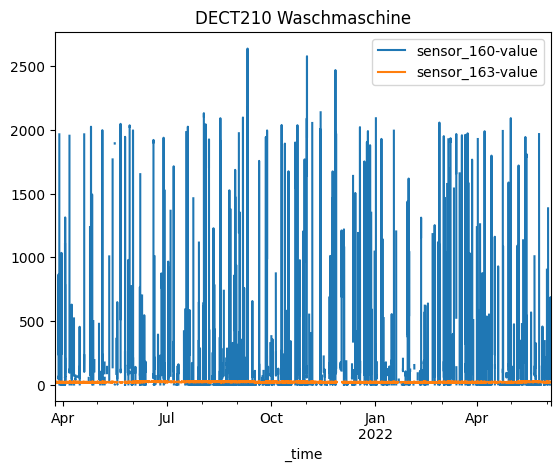

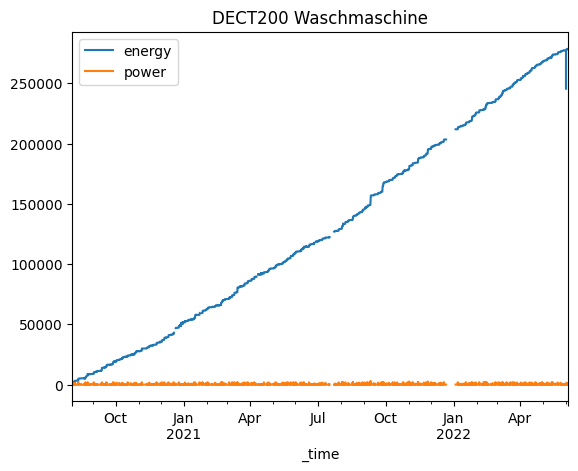

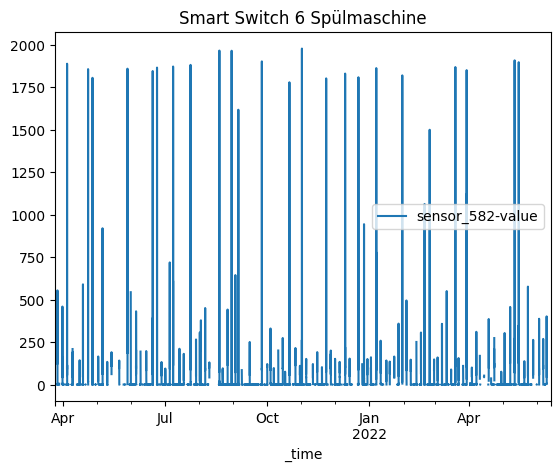

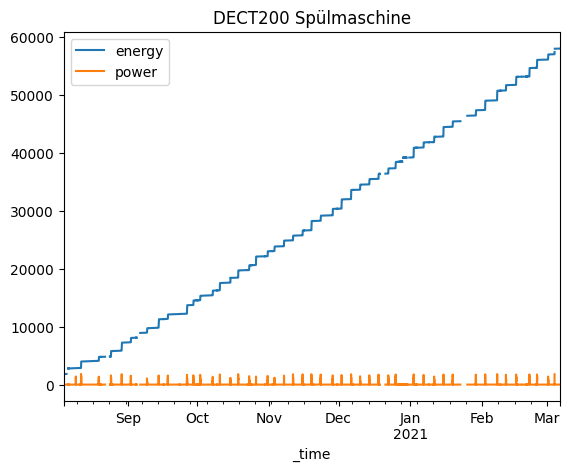

In [7]:
for tn, s in series.items():
    s.plot(title=tn)